#  **Analisis Klasifikasi dengan Dataset Iris**

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [83]:
## Latihan Analisis Klasifikasi dengan Dataset Iris

In [69]:
data = pd.read_csv('Iris.csv')
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [71]:
data.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [72]:
data.duplicated().sum()

np.int64(0)

In [73]:
data = data.drop(columns = 'Id')
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


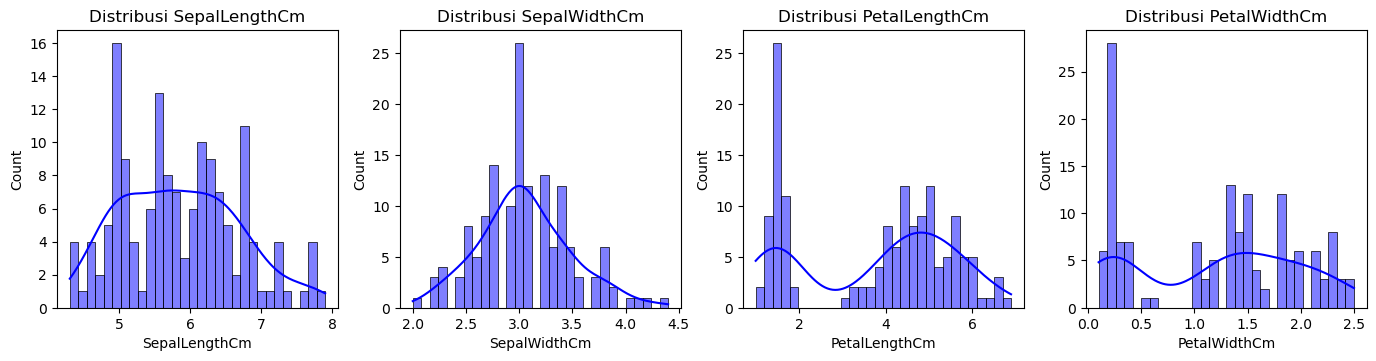

In [74]:
# Distribusi fitur numerik
num_features = data.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10)) # Membuat figure dengan ukuran yang lebih besar untuk menampung semua subplot
for i, column in enumerate(num_features.columns, 1): # Loop melalui setiap fitur numerik
    plt.subplot(3, 4, i) # Membuat subplot untuk setiap fitur numerik
    sns.histplot(data[column], bins=30, kde=True, color='blue') # Membuat histogram dengan garis KDE untuk setiap fitur numerik
    plt.title(f'Distribusi {column}') # Menambahkan judul untuk setiap subplot
plt.tight_layout() # Mengatur tata letak agar tidak tumpang tindih
plt.show()

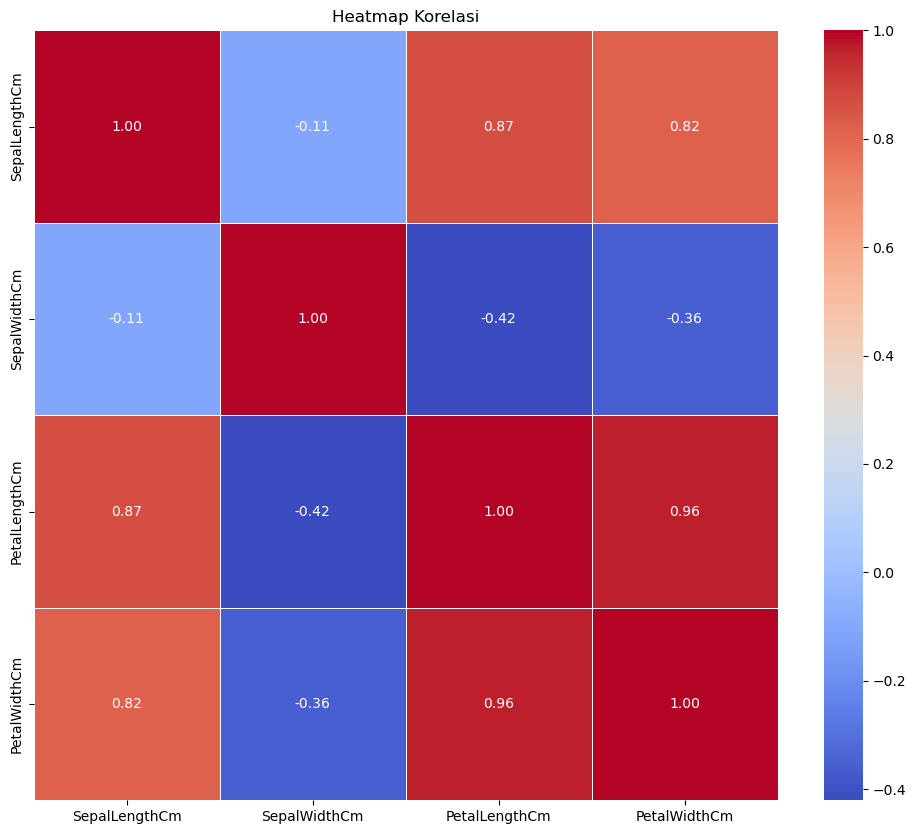

In [75]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

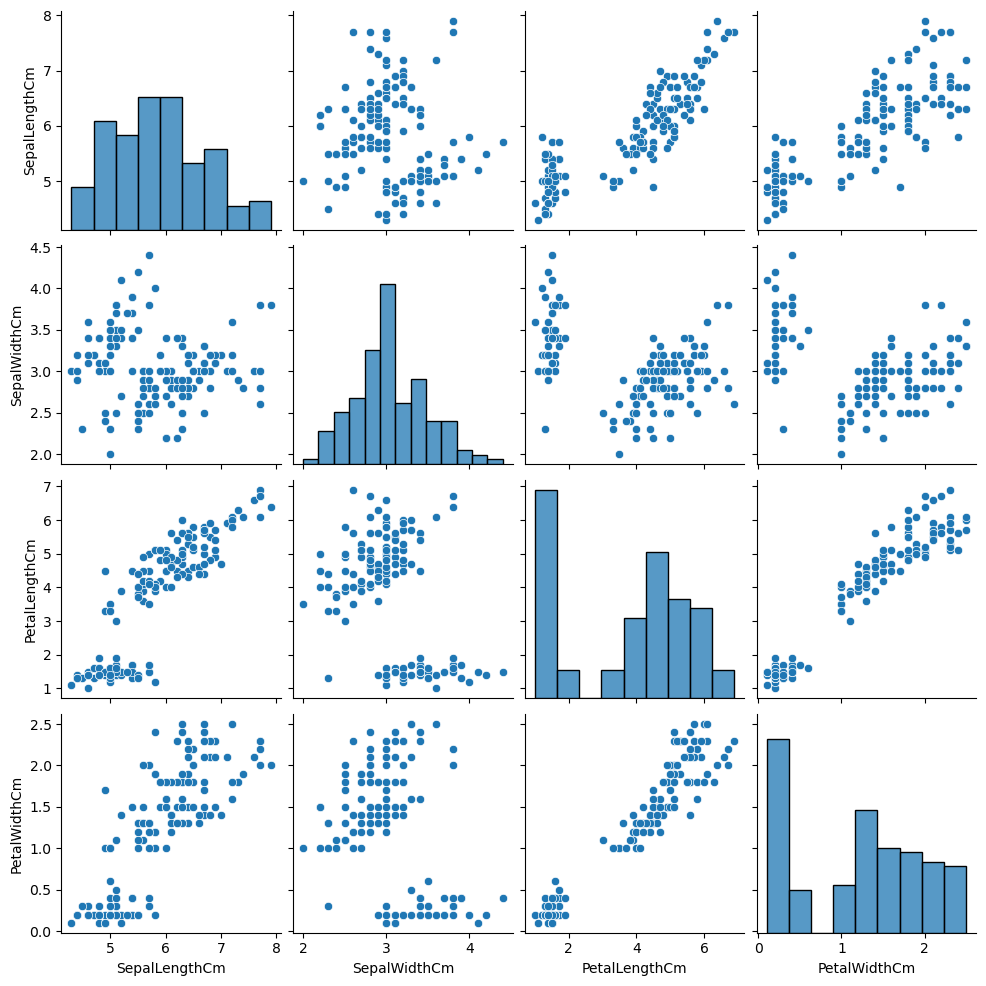

In [76]:
# Pairplot untuk fitur numerik
sns.pairplot(num_features)
plt.show()

C:\Users\ihsan\AppData\Local\Temp\ipykernel_14688\3224364356.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=data, palette='viridis') # x adalah variabel target


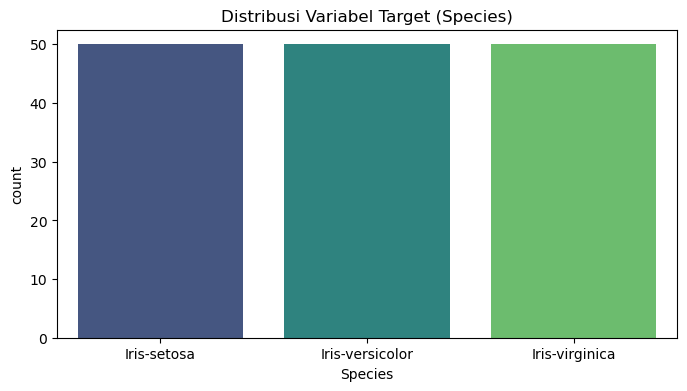

In [77]:
# Visualisasi distribusi variabel target
plt.figure(figsize=(8, 4))
sns.countplot(x='Species', data=data, palette='viridis') # x adalah variabel target
plt.title('Distribusi Variabel Target (Species)')
plt.show()

In [78]:
# Buat instance MinMaxScaler
scaler = MinMaxScaler()
 
# Pisahkan fitur (X) dan target (y)
X = data.drop(columns=['Species'])
y = data['Species']
 
# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
 
# Normalisasi semua kolom numerik
numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])
 
# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(105, 4), y_train=(105,)
Test set shape: X_test=(45, 4), y_test=(45,)


In [79]:
# Melatih Model
# Mendefinisikan setiap klasifikasi secara terpisah
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)
 
print("Model training selesai.")

Model training selesai.


In [80]:
# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai kamus
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    # tn, fp, fn, tp = cm.ravel() # pada kasus multi-kelas, kita tidak bisa menggunakan ravel() untuk mendapatkan tp, fp, fn, tn secara langsung
    results = {
        'Confusion Matrix': cm,
        # 'True Positive (TP)': tp,
        # 'False Positive (FP)': fp,
        # 'False Negative (FN)': fn,
        # 'True Negative (TN)': tn,
        'Accuracy': accuracy_score(y_test, y_pred) , #tidak perlu average untuk accuracy_score karena itu sudah memberikan skor keseluruhan
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    }
    return results
 
# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test)
}
 
# Buat DataFrame untuk meringkas hasil
summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
 
# Isi DataFrame dengan hasil
rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })
 
# Konversi daftar kamus ke DataFrame
summary_df = pd.DataFrame(rows)
 
# Tampilkan DataFrame
print(summary_df)

                          Model  Accuracy  Precision    Recall  F1-Score
0     K-Nearest Neighbors (KNN)  1.000000   1.000000  1.000000  1.000000
1            Decision Tree (DT)  1.000000   1.000000  1.000000  1.000000
2            Random Forest (RF)  1.000000   1.000000  1.000000  1.000000
3  Support Vector Machine (SVM)  1.000000   1.000000  1.000000  1.000000
4              Naive Bayes (NB)  0.977778   0.979365  0.977778  0.977745


In [81]:
from sklearn.model_selection import cross_val_score

# Cross-validation KNN
scores = cross_val_score(knn, X, y, cv=5)
print(f"Akurasi tiap fold: {scores}")
print(f"Rata-rata Akurasi: {scores.mean()}")

Akurasi tiap fold: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Rata-rata Akurasi: 0.9733333333333334


In [82]:
# Cross validation untuk semua model
model = [knn, dt, rf, svm, nb
         ]
for i in model:
    scores = cross_val_score(i, X, y, cv=5)
    print(f"Akurasi tiap fold untuk {i.__class__.__name__}: {scores}")
    print(f"Rata-rata Akurasi untuk {i.__class__.__name__}: {scores.mean()}\n")

Akurasi tiap fold untuk KNeighborsClassifier: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Rata-rata Akurasi untuk KNeighborsClassifier: 0.9733333333333334

Akurasi tiap fold untuk DecisionTreeClassifier: [0.96666667 0.96666667 0.9        1.         1.        ]
Rata-rata Akurasi untuk DecisionTreeClassifier: 0.9666666666666668

Akurasi tiap fold untuk RandomForestClassifier: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Rata-rata Akurasi untuk RandomForestClassifier: 0.96

Akurasi tiap fold untuk SVC: [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Rata-rata Akurasi untuk SVC: 0.9666666666666666

Akurasi tiap fold untuk GaussianNB: [0.93333333 0.96666667 0.93333333 0.93333333 1.        ]
Rata-rata Akurasi untuk GaussianNB: 0.9533333333333334

